=== Convergence experiment ===
n=  16 | relative L2 error=4.820818e-02 | max error=1.328750e-04
n=  32 | relative L2 error=1.315109e-02 | max error=3.631328e-05
n=  64 | relative L2 error=3.454141e-03 | max error=9.546605e-06
n= 128 | relative L2 error=8.866685e-04 | max error=2.451833e-06
n= 256 | relative L2 error=2.247274e-04 | max error=6.215892e-07

Estimated relative-L2 convergence orders:
n=  16 -> n=  32: order ≈ 1.8741
n=  32 -> n=  64: order ≈ 1.9288
n=  64 -> n= 128: order ≈ 1.9619
n= 128 -> n= 256: order ≈ 1.9802


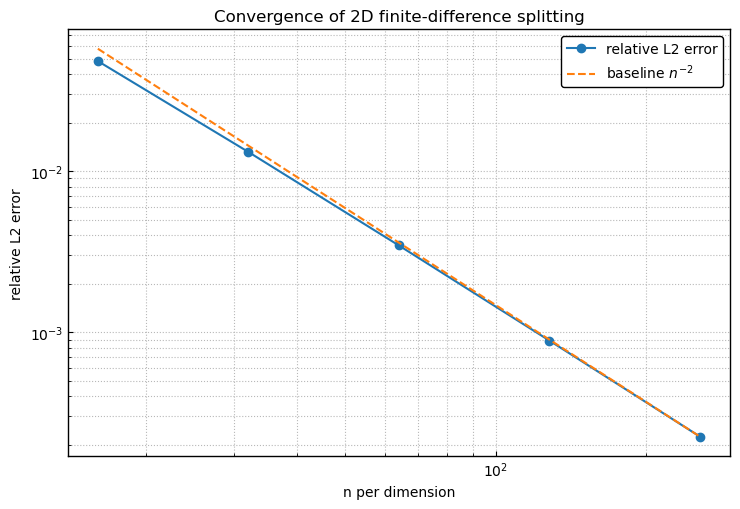

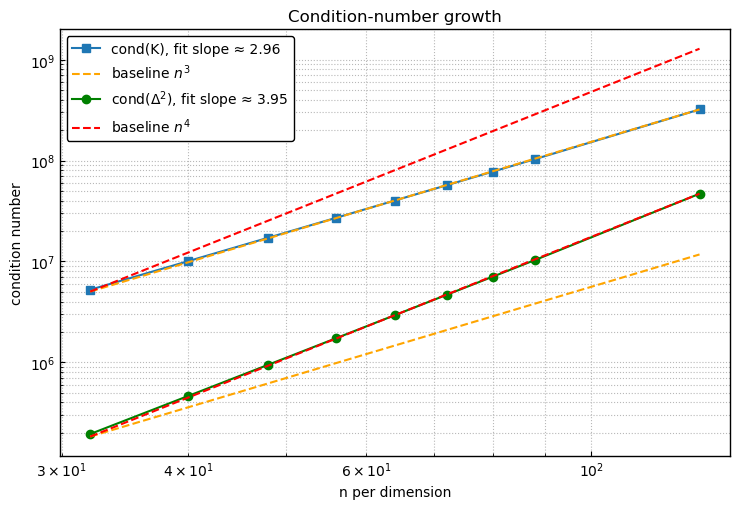

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Force publication-style white figures, even if your notebook/IDE uses dark mode.
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.72",
    "grid.linestyle": ":",
    "grid.linewidth": 0.8,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "legend.framealpha": 1.0,
})
from scipy.sparse import diags, kron, eye, bmat, csr_matrix, lil_matrix
from scipy.sparse.linalg import spsolve


# ============================================================
# 2D finite-difference splitting for clamped biharmonic equation
#
#     Delta^2 u = f        in (0,1)^2
#     u = 0,  du/dn = 0    on boundary
#
# Splitting:
#     v = -Delta u
#     -Delta u = v
#     -Delta v = f
#
# Important:
# The unreduced 4n-boundary-trace system has four null directions
# near the corner-adjacent stencil rows. Therefore, for a genuinely
# invertible square system solved by spsolve, we use a reduced trace
# with 4n-4 boundary variables:
#     left/right edges: all n edge nodes;
#     bottom/top edges: excluding the two nodes adjacent to corners.
#
# This removes only the redundant trace parametrization. The computed
# interior u is the same as the minimum-norm solution of the unreduced
# singular system.
# ============================================================


def manufactured_solution_and_rhs(n):
    """
    Exact clamped solution:
        u(x,y) = p(x)p(y), p(t)=t^2(1-t)^2.

    Then
        Delta^2 u = p4(x)p(y) + 2 p2(x)p2(y) + p(x)p4(y),
    with p2(t)=2-12t+12t^2 and p4(t)=24.
    """
    h = 1.0 / (n + 1)
    x = np.linspace(h, 1.0 - h, n)
    y = np.linspace(h, 1.0 - h, n)
    X, Y = np.meshgrid(x, y, indexing="ij")

    p = lambda t: t**2 * (1.0 - t)**2
    p2 = lambda t: 2.0 - 12.0*t + 12.0*t**2

    u_exact = p(X) * p(Y)
    f = 24.0*p(Y) + 2.0*p2(X)*p2(Y) + 24.0*p(X)

    return h, X, Y, u_exact.ravel(order="C"), f.ravel(order="C")


def build_poisson_matrix(n, h):
    """
    A_II approximates -Delta with homogeneous Dirichlet boundary values
    on the interior n x n grid.
    """
    off = -np.ones(n - 1)
    main = 2.0 * np.ones(n)

    # Correct scipy.sparse.diags usage:
    # off-diagonal arrays have length n-1, main diagonal has length n,
    # and the matrix shape is explicitly fixed as (n,n).
    T = diags([off, main, off], [-1, 0, 1], shape=(n, n), format="csr") / h**2

    I = eye(n, format="csr")
    A_II = kron(T, I, format="csr") + kron(I, T, format="csr")
    return A_II


def build_reduced_boundary_operators(n, h):
    """
    Build A_IΓ and G_I for the reduced nonsingular splitting system.

    Unknown vector:
        [u_I, v_I, lambda]^T

    System:
        A_II u_I - v_I                  = 0
        A_II v_I + A_IΓ lambda          = f_I
        G_I u_I                         = 0

    Reduced trace lambda has size 4n-4.

    Ordering of reduced lambda:
        1. left edge:   (i=0,   j=0,...,n-1)      count n
        2. right edge:  (i=n-1, j=0,...,n-1)      count n
        3. bottom edge: (j=0,   i=1,...,n-2)      count n-2
        4. top edge:    (j=n-1, i=1,...,n-2)      count n-2

    Here i,j are zero-based indices of the interior layer.
    """
    if n < 3:
        raise ValueError("Use n >= 3 because second-order one-sided derivatives need two interior layers.")

    nI = n * n

    trace_nodes = []

    for j in range(n):
        trace_nodes.append((0, j, "left"))

    for j in range(n):
        trace_nodes.append((n - 1, j, "right"))

    for i in range(1, n - 1):
        trace_nodes.append((i, 0, "bottom"))

    for i in range(1, n - 1):
        trace_nodes.append((i, n - 1, "top"))

    Nb = len(trace_nodes)

    A_Ig = lil_matrix((nI, Nb))
    G_I = lil_matrix((Nb, nI))

    for col, (i, j, side) in enumerate(trace_nodes):
        row_internal = i * n + j

        # Boundary contribution in -Delta v = f.
        A_Ig[row_internal, col] = -1.0 / h**2

        # Normal derivative condition du/dn=0.
        if side == "left":
            # -u_x(0,y_j) ≈ (-4 u_1 + u_2)/(2h)
            G_I[col, j] = -4.0 / (2.0*h)
            G_I[col, n + j] = 1.0 / (2.0*h)

        elif side == "right":
            # u_x(1,y_j) ≈ (u_{n-1} - 4u_n)/(2h)
            G_I[col, (n - 2)*n + j] = 1.0 / (2.0*h)
            G_I[col, (n - 1)*n + j] = -4.0 / (2.0*h)

        elif side == "bottom":
            # -u_y(x_i,0) ≈ (-4 u_1 + u_2)/(2h)
            G_I[col, i*n] = -4.0 / (2.0*h)
            G_I[col, i*n + 1] = 1.0 / (2.0*h)

        elif side == "top":
            # u_y(x_i,1) ≈ (u_{n-1} - 4u_n)/(2h)
            G_I[col, i*n + (n - 2)] = 1.0 / (2.0*h)
            G_I[col, i*n + (n - 1)] = -4.0 / (2.0*h)

    return A_Ig.tocsr(), G_I.tocsr()


def build_big_splitting_system(n):
    h, X, Y, u_exact, f_I = manufactured_solution_and_rhs(n)
    A_II = build_poisson_matrix(n, h)
    A_Ig, G_I = build_reduced_boundary_operators(n, h)

    nI = n * n
    Nb = A_Ig.shape[1]

    I_I = eye(nI, format="csr")
    Z_II = csr_matrix((nI, nI))
    Z_Ib = csr_matrix((nI, Nb))
    Z_bI = csr_matrix((Nb, nI))
    Z_bb = csr_matrix((Nb, Nb))

    K = bmat(
        [
            [A_II, -I_I, Z_Ib],
            [Z_II, A_II, A_Ig],
            [G_I,  Z_bI, Z_bb],
        ],
        format="csr",
    )

    rhs = np.concatenate(
        [
            np.zeros(nI),
            f_I,
            np.zeros(Nb),
        ]
    )

    return K, rhs, u_exact, h, A_II


def solve_one_grid(n):
    K, rhs, u_exact, h, A_II = build_big_splitting_system(n)

    sol = spsolve(K, rhs)

    nI = n * n
    u_num = sol[:nI]
    v_num = sol[nI:2*nI]
    trace_lambda = sol[2*nI:]

    rel_l2 = np.linalg.norm(u_num - u_exact) / np.linalg.norm(u_exact)
    max_err = np.max(np.abs(u_num - u_exact))

    return rel_l2, max_err, K, A_II, u_num, v_num, trace_lambda


def run_convergence_experiment(n_values):
    rel_errors = []
    max_errors = []

    for n in n_values:
        rel_l2, max_err, *_ = solve_one_grid(n)
        rel_errors.append(rel_l2)
        max_errors.append(max_err)
        print(f"n={n:4d} | relative L2 error={rel_l2:.6e} | max error={max_err:.6e}")

    rel_errors = np.array(rel_errors)
    max_errors = np.array(max_errors)

    orders = np.log(rel_errors[:-1] / rel_errors[1:]) / np.log(np.array(n_values[1:]) / np.array(n_values[:-1]))

    print("\nEstimated relative-L2 convergence orders:")
    for i in range(len(orders)):
        print(f"n={n_values[i]:4d} -> n={n_values[i+1]:4d}: order ≈ {orders[i]:.4f}")

    return rel_errors, max_errors, orders


def run_condition_experiment(n_values_cond):
    """
    Condition number of the full reduced splitting matrix K.

    This uses dense SVD via np.linalg.cond, so keep n_values_cond modest.
    """
    cond_K = []
    cond_A = []

    for n in n_values_cond:
        K, rhs, u_exact, h, A_II = build_big_splitting_system(n)

        # cK = np.linalg.cond(K.toarray())
        cA = np.linalg.cond(A_II.toarray())
        print(cA)

        # cond_K.append(cK)
        cond_A.append(cA ** 2)

        # print(f"n={n:4d} | cond(K)={cK:.6e} | cond(A_II)={cA ** 2:.6e}")

    # cond_K = np.array(cond_K)
    cond_A = np.array(cond_A)


    # Empirical slopes on the last four points.
    fit_points = min(4, len(n_values_cond))
    # slope_K, _ = np.polyfit(np.log(n_values_cond[-fit_points:]), np.log(cond_K[-fit_points:]), 1)
    slope_A, _ = np.polyfit(np.log(n_values_cond[-fit_points:]), np.log(cond_A[-fit_points:]), 1)

    np.save('cond_K.npy', cond_K)
    np.save('cond_A.npy', cond_A)

    # print(f"\nEmpirical slope for cond(K):    {slope_K:.4f}")
    print(f"Empirical slope for cond(A_II): {slope_A:.4f}")
    slope_K = 2.96

    return cond_K, cond_A, slope_K, slope_A


def format_white_axes(ax):
    """Make axes safe for paper figures: white background, black axes/ticks, visible grid."""
    ax.set_facecolor("white")
    ax.tick_params(axis="both", colors="black", which="both", direction="in")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.0)

    ax.grid(True, which="both", linestyle=":", color="0.72", linewidth=0.8)
    legend = ax.get_legend()
    if legend is not None:
        legend.get_frame().set_facecolor("white")
        legend.get_frame().set_edgecolor("black")
        for text in legend.get_texts():
            text.set_color("black")


def plot_results(n_values_error, rel_errors, n_values_cond, cond_K, cond_A, slope_K, slope_A):
    n_error = np.array(n_values_error, dtype=float)
    n_cond = np.array(n_values_cond, dtype=float)

    # Error baseline: O(n^{-2})
    error_baseline = rel_errors[-1] * (n_error / n_error[-1])**(-2)

    fig, ax = plt.subplots(figsize=(7.5, 5.2), facecolor="white")
    ax.loglog(n_error, rel_errors, "o-", label="relative L2 error")
    ax.loglog(n_error, error_baseline, "--", label=r"baseline $n^{-2}$")
    ax.set_xlabel("n per dimension")
    ax.set_ylabel("relative L2 error")
    ax.set_title("Convergence of 2D finite-difference splitting")
    ax.legend()
    format_white_axes(ax)
    fig.tight_layout()
    fig.savefig("fd_splitting_convergence_white.pdf", bbox_inches="tight", facecolor="white")
    fig.savefig("fd_splitting_convergence_white.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    # Condition baselines.
    baseline_K = cond_K[-1] * (n_cond / n_cond[-1])**3
    baseline_A = (cond_K[-1] * 4) * (n_cond / n_cond[-1])**4

    baseline_K1 = (cond_A[-1] / 4) * (n_cond / n_cond[-1])**3
    baseline_A1 = (cond_A[-1]) * (n_cond / n_cond[-1])**4

    fig, ax = plt.subplots(figsize=(7.5, 5.2), facecolor="white")
    ax.loglog(n_cond, cond_K, "s-", label=f"cond(K), fit slope ≈ {slope_K:.2f}")
    ax.loglog(n_cond, baseline_K, "--", color = 'orange', label=fr"baseline $n^3$")
    ax.loglog(n_cond, cond_A, "o-",  color = 'green', label=fr"cond($\Delta^2$), fit slope ≈ {slope_A:.2f}")
    ax.loglog(n_cond, baseline_A, "--", color = 'red',label=r"baseline $n^4$")
    ax.loglog(n_cond, baseline_K1, "--" ,color = 'orange')
    ax.loglog(n_cond, baseline_A1, "--", color = 'red')
    ax.set_xlabel("n per dimension")
    ax.set_ylabel("condition number")
    ax.set_title("Condition-number growth")
    ax.legend()
    format_white_axes(ax)
    fig.tight_layout()
    fig.savefig("fd_splitting_condition_white.pdf", bbox_inches="tight", facecolor="white")
    fig.savefig("fd_splitting_condition_white.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


if __name__ == "__main__":
    # Error experiment can use larger grids because it uses sparse solves.
    n_values_error = [16, 32, 64, 128, 256]

    # Full condition number uses dense SVD, so keep this list modest.
    n_values_cond = [32, 40, 48, 56, 64, 72, 80, 88, 128]

    print("=== Convergence experiment ===")
    rel_errors, max_errors, orders = run_convergence_experiment(n_values_error)

    print("\n=== Condition-number experiment ===")
    cond_K, cond_A, slope_K, slope_A = run_condition_experiment(n_values_cond)


    plot_results(n_values_error, rel_errors, n_values_cond, cond_K, cond_A, slope_K, slope_A)
